# 10 — ผลบน test ปี 2025 (ประเมินครั้งเดียว)

ผลทั้งหมดมาจาก `python -m src.evaluate_test --run` ที่รัน**ครั้งเดียว** หลังประกาศเกณฑ์ไว้ใน ROADMAP (commit `1641d10`, `1443ff9`) ก่อนเปิดข้อมูล
notebook นี้**อ่านเฉพาะผลที่บันทึกไว้** (`docs/test_2025_results.json`, `docs/test_2025_noon.csv`, `dataset/processed/test_2025_predictions.parquet`) ไม่ได้ fit หรือปรับอะไรใหม่ หลังเห็นผลไม่มีการแก้โมเดล features params หรือ Q

- **โมเดล:** refit บน 2023–2024
  - UVI/UVA/UVB ค่าเดียวจาก MultiOutput XGBoost (params วัน 8)
  - ช่วงและการเตือนจาก quantile XGBoost + CQR Q = +0.0379 เตือนด้วย q90
- **แหล่งอ้างอิง:** NASA POWER รายชั่วโมง (target), OMI (UVI ฟ้ามีเมฆและ irradiance ตอนเที่ยง), TEMIS (UVI ฟ้าใสตอนเที่ยง) **ไม่มีเครื่องวัด UV ภาคพื้นดิน** ทุกแหล่งเป็นดาวเทียมหรือแบบจำลอง

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> source_code/ -> Final-Project/
sys.path.insert(0, str(ROOT / "source_code"))

FIG_DIR = ROOT / "docs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# reference palette (dataviz skill): fixed categorical order, recessive axes
C_OM, C_NASA, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 100,
})


def save(fig, name):
    """Save a figure to docs/figures at 150 dpi."""
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")

In [2]:
import json

from src.metrics import regression_metrics
from src.train_cmf import MODEL_DIR

docs = ROOT / "docs"
res = json.loads((docs / "test_2025_results.json").read_text(encoding="utf-8"))
crit = pd.read_csv(docs / "test_2025_criteria.csv")
noon = pd.read_csv(docs / "test_2025_noon.csv", parse_dates=["date"])
pred = pd.read_parquet(ROOT / "dataset" / "processed" / "test_2025_predictions.parquet")
print(f"test rows {res['n_test_rows']}, criteria passed {int(crit['passed'].sum())}/{len(crit)}")
crit.assign(value=crit["value"].round(3))

test rows 3718, criteria passed 14/15


,id,desc,value,threshold,passed
0,T1,model hourly UVI MAE vs NASA POWER 2025 (check...,0.479,< 1.0,True
1,T1b,model hourly MAE < every baseline's MAE vs NAS...,0.479,< min baseline 0.708,True
2,T2a,model noon MAE vs OMI all-sky <= 1.5 UVI,1.320,<= 1.5,True
3,T2b,model noon MAE vs OMI <= NASA POWER noon MAE v...,1.320,<= NASA 1.330 + 0.3,True
4,T2c,model noon MAE vs OMI < every baseline's MAE v...,1.320,< min baseline 1.960,True
5,T3a,physics clear-sky noon UVI vs TEMIS (all days)...,0.764,<= 1.0,True
6,T3b,model noon MAE vs TEMIS on clear days <= 1.5 UVI,1.360,<= 1.5,True
7,T3c,model noon MAE vs TEMIS on clear days <= NASA ...,1.360,<= NASA 1.580 + 0.3,True
8,T4,Pearson r model UVB vs OMI 305/310 nm and UVA ...,0.533,>= 0.7 (all 4 pairs),False
9,T4b,each T4 r >= the physics clear-sky r for the s...,0.121,">= 0 (model r - physics r, all pairs)",True


## 1. เทียบ NASA POWER รายชั่วโมง (T1, T1b) และเทียบกับผล dev

In [3]:
h = res["hourly_vs_nasa"]
t = pd.DataFrame(h["vs_nasa"]).T[["n", "mae", "bias", "rmse", "r"]]
display(t.round(3))
dev_v2 = json.loads((MODEL_DIR / "cmf_multi_xgb_v2_metrics.json").read_text(encoding="utf-8"))
cmp = pd.DataFrame(
    {
        "dev 2024 (fit 2023, optimistic)": [dev_v2["dev"]["uvi"]["uvi"]["mae"], dev_v2["dev"]["uva"]["mae"],
                                            dev_v2["dev"]["uvb"]["mae"]],
        "test 2025 (fit 2023-2024)": [h["vs_nasa"]["model"]["mae"], h["uva_vs_nasa"]["mae"], h["uvb_vs_nasa"]["mae"]],
    },
    index=["UVI MAE", "UVA MAE (W/m²)", "UVB MAE (W/m²)"],
)
cmp.round(3)

,n,mae,bias,rmse,r
model,3718.0,0.479,0.106,0.752,0.967
open_meteo,3718.0,1.244,0.004,1.679,0.821
physics_clear,3718.0,2.471,2.471,3.052,0.939
physics_const_cmf,3718.0,0.708,-0.116,1.023,0.939


,"dev 2024 (fit 2023, optimistic)",test 2025 (fit 2023-2024)
UVI MAE,0.450,0.479
UVA MAE (W/m²),2.871,2.910
UVB MAE (W/m²),0.084,0.088


## 2. เทียบ OMI ฟ้ามีเมฆ และ TEMIS ฟ้าใส ตอนเที่ยงสุริยะ (T2, T3)

In [4]:
v = res["validation"]
rows = []
for blk, label in [("omi", "OMI all-sky"), ("temis_all_days", "TEMIS clear-sky, all days"),
                   ("temis_clear_days", "TEMIS clear-sky, NASA cloud < 10 %")]:
    for k, m in v[blk].items():
        rows.append({"reference": label, "estimator": k, **m})
pd.DataFrame(rows).round(3)

,reference,estimator,n,mae,bias,rmse,r
0,OMI all-sky,model,269,1.320,-0.822,1.661,0.631
1,OMI all-sky,open_meteo,269,2.356,-2.120,2.997,0.338
2,OMI all-sky,physics_clear,269,3.215,3.215,3.662,0.505
3,OMI all-sky,physics_const_cmf,269,1.960,-1.490,2.189,0.505
4,OMI all-sky,nasa_power,269,1.330,-0.966,1.710,0.662
5,"TEMIS clear-sky, all days",physics_clear,365,0.764,0.689,0.885,0.949
6,"TEMIS clear-sky, NASA cloud < 10 %",model,62,1.360,-1.359,1.639,0.903
7,"TEMIS clear-sky, NASA cloud < 10 %",open_meteo,62,2.310,-2.310,2.471,0.972
8,"TEMIS clear-sky, NASA cloud < 10 %",physics_clear,62,0.856,0.831,0.942,0.966
9,"TEMIS clear-sky, NASA cloud < 10 %",physics_const_cmf,62,3.241,-3.241,3.307,0.966


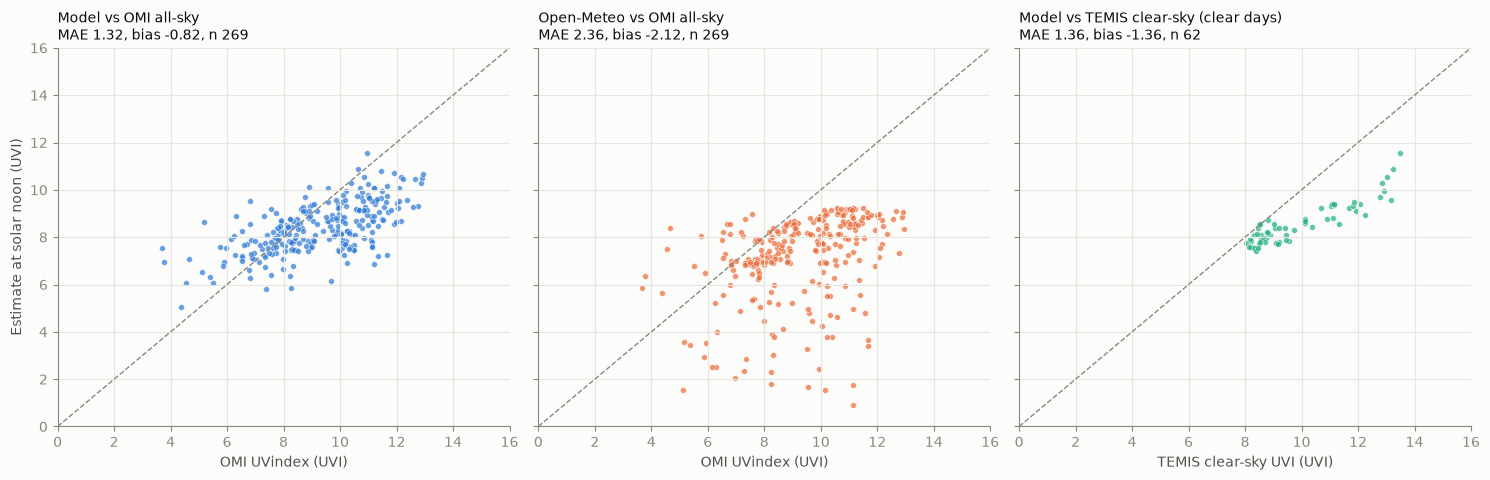

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9), sharex=True, sharey=True)
lim = 16
omi_ok = noon.dropna(subset=["UVindex", "uvi", "om_uvi", "nasa_uvi"])
clear = noon[(noon["nasa_cloud_pct"] < 10)].dropna(subset=["temis_uvi_clear", "uvi", "phys_clear"])
panels = [
    (axes[0], omi_ok["UVindex"], omi_ok["uvi"], C_OM, "Model vs OMI all-sky", "OMI UVindex (UVI)"),
    (axes[1], omi_ok["UVindex"], omi_ok["om_uvi"], C_NASA, "Open-Meteo vs OMI all-sky", "OMI UVindex (UVI)"),
    (axes[2], clear["temis_uvi_clear"], clear["uvi"], C_THIRD, "Model vs TEMIS clear-sky (clear days)",
     "TEMIS clear-sky UVI (UVI)"),
]
for ax, x, y, c, title, xl in panels:
    d = y - x
    ax.scatter(x, y, s=18, color=c, alpha=0.7, edgecolors="#fcfcfb", linewidths=0.5)
    ax.plot([0, lim], [0, lim], color=MUTED, lw=1, ls="--")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"{title}\nMAE {d.abs().mean():.2f}, bias {d.mean():+.2f}, n {len(d)}", loc="left", fontsize=10)
    ax.set_xlabel(xl)
axes[0].set_ylabel("Estimate at solar noon (UVI)")
fig.tight_layout()
save(fig, "test2025_noon_scatter.png")

## 3. OMI irradiance เทียบ UVA/UVB ของโมเดล (T4, Pearson r)

,n,pearson_model,spearman_model,pearson_physics_clear
uvb_vs_Irradiance305,269.0,0.646,0.637,0.525
uvb_vs_Irradiance310,269.0,0.630,0.625,0.436
uva_vs_Irradiance324,269.0,0.533,0.480,0.313
uva_vs_Irradiance380,269.0,0.572,0.527,0.203


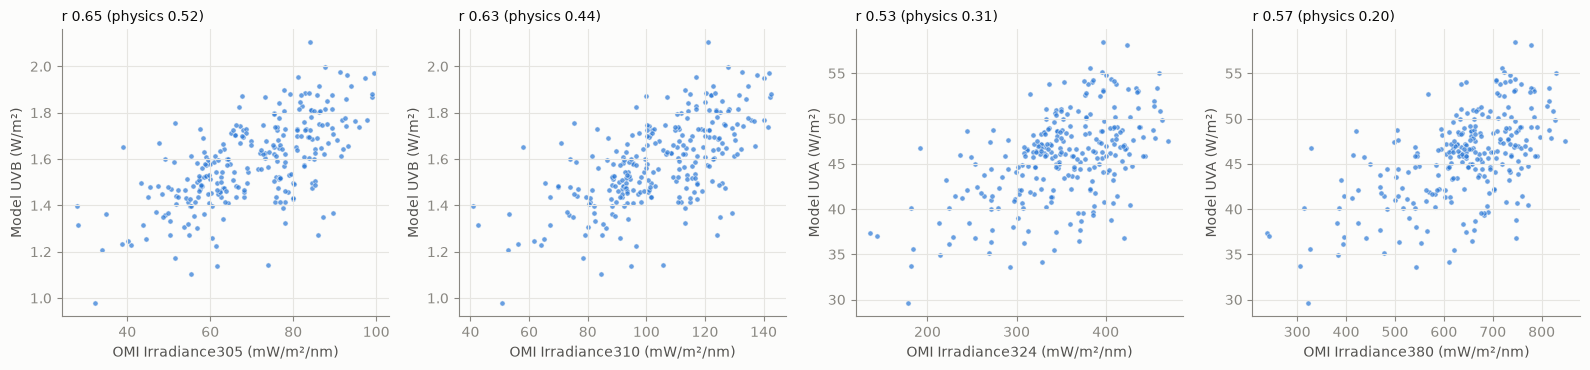

In [6]:
irr = pd.DataFrame(v["irradiance"]).T
display(irr.round(3))
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (key, row) in zip(axes, irr.iterrows()):
    band, field = key.split("_vs_")
    d = noon.dropna(subset=[band, field])
    ax.scatter(d[field], d[band], s=14, color=C_OM, alpha=0.7, edgecolors="#fcfcfb", linewidths=0.5)
    unit = "W/m²"
    ax.set_xlabel(f"OMI {field} (mW/m²/nm)")
    ax.set_ylabel(f"Model {band.upper()} ({unit})")
    ax.set_title(f"r {row['pearson_model']:.2f} (physics {row['pearson_physics_clear']:.2f})", loc="left", fontsize=10)
fig.tight_layout()
save(fig, "test2025_irradiance.png")

## 4. ช่วง CQR และการเตือนด้วย q90 (T5, T6)

In [7]:
print("interval:", {k: round(x, 3) for k, x in h["interval"].items()})
display(pd.DataFrame(h["alerts_q90"]).T.round(3))
cm = pd.DataFrame(h["who_q90"]["confusion"], index=h["who_q90"]["labels"], columns=h["who_q90"]["labels"])
print("Confusion matrix, level of q90 (rows = NASA level):")
display(cm)
rec = h["who_q90"]["recall"]
print(f"recall (exact level, q90): Very high {rec['Very high']:.3f}, Extreme {rec['Extreme']:.3f}")

interval: {'n': 3718, 'coverage': 0.806, 'below': 0.14, 'above': 0.054, 'width': 1.463}


,n_events,n_alerts,tp,fp,fn,recall,precision,false_alarm_rate
Very high,654.0,1144.0,645.0,499.0,9.0,0.986,0.564,0.163
Extreme,23.0,110.0,19.0,91.0,4.0,0.826,0.173,0.025


Confusion matrix, level of q90 (rows = NASA level):


,Low,Moderate,High,Very high,Extreme
Low,1087,201,5,3,0
Moderate,0,651,297,67,0
High,0,5,319,425,4
Very high,0,0,9,535,87
Extreme,0,0,0,4,19


recall (exact level, q90): Very high 0.848, Extreme 0.826


In [8]:
# Wilson 95 % interval for the Extreme recall (only a few events)
from scipy.stats import norm

def wilson(k, n, z=norm.ppf(0.975)):
    p = k / n
    c = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    w = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return c - w, c + w

ex = h["alerts_q90"]["Extreme"]
lo, hi = wilson(ex["tp"], ex["n_events"])
print(f"Extreme recall {ex['tp']}/{ex['n_events']} = {ex['recall']:.3f}, 95 % CI {lo:.2f}-{hi:.2f}")

Extreme recall 19/23 = 0.826, 95 % CI 0.63-0.93


## 5. บันทึก metrics ของโมเดลสุดท้าย (`*_final_metrics.json`)

In [9]:
from src.evaluate_test import MULTI_PATH, QUANT_PATH

reg = regression_metrics(pred["nasa_uvi"], pred["uvi"])
common = {"created": res["created"], "features": res["features"], "fit": "2023-2024",
          "evaluated": "test 2025 once (docs/test_2025_results.json)", "fold_scores": "see cmf_multi_xgb_v2_metrics.json (CV 2023-2024)"}
(MODEL_DIR / "cmf_multi_xgb_final_metrics.json").write_text(json.dumps({
    "model": MULTI_PATH.name, **common, "scale": "UVI on test 2025 vs NASA POWER",
    "mae": reg["mae"], "rmse": reg["rmse"], "r2": reg["r2"], "bias": reg["bias"],
    "uva_vs_nasa": h["uva_vs_nasa"], "uvb_vs_nasa": h["uvb_vs_nasa"],
}, indent=2, ensure_ascii=False), encoding="utf-8")
(MODEL_DIR / "cmf_uvi_quantile_xgb_final_metrics.json").write_text(json.dumps({
    "model": QUANT_PATH.name, **common, "cqr_q_cmf": res["cqr_q_cmf"],
    "interval": h["interval"], "alerts_q90": h["alerts_q90"], "who_q90": h["who_q90"],
    "mae": regression_metrics(pred["nasa_uvi"], pred["q50"])["mae"],
    "rmse": regression_metrics(pred["nasa_uvi"], pred["q50"])["rmse"],
    "r2": regression_metrics(pred["nasa_uvi"], pred["q50"])["r2"],
}, indent=2, ensure_ascii=False, default=float), encoding="utf-8")
reg

{'n': 3718,
 'mae': 0.4792695027210836,
 'rmse': 0.7516022980529706,
 'r2': 0.9341168310639808,
 'bias': 0.10619160040590624}

## สรุปผล test 2025 (ประเมินครั้งเดียว)

**ผ่าน 14 / 15 เกณฑ์ที่ประกาศไว้ ไม่ผ่าน T4** Checkpoint วัน 10 (MAE < 1.0 UVI) ผ่าน

| # | ผล 2025 | เกณฑ์ | ผ่าน |
|---|---|---|---|
| T1 | MAE รายชั่วโมงเทียบ NASA **0.479** (R² 0.934, bias +0.11; dev 2024 0.450) | < 1.0 | ✅ |
| T1b | baseline: physics × CMF คงที่ 0.708, Open-Meteo 1.244, physics ฟ้าใส 2.471 | ต่ำกว่าทุกตัว | ✅ |
| T2a | MAE ตอนเที่ยงเทียบ OMI **1.32** (bias −0.82, n 269) | ≤ 1.5 | ✅ |
| T2b | NASA POWER เทียบ OMI 1.33 | ≤ 1.63 | ✅ |
| T2c | baseline เทียบ OMI: CMF คงที่ 1.96, Open-Meteo 2.36, physics ฟ้าใส 3.22 | ต่ำกว่าทุกตัว | ✅ |
| T3a | physics ฟ้าใสเทียบ TEMIS (ทุกวัน) **0.76** (bias +0.69, r 0.95) | ≤ 1.0 | ✅ |
| T3b | โมเดลเทียบ TEMIS วันฟ้าเปิด **1.36** (bias −1.36, n 62) | ≤ 1.5 | ✅ |
| T3c | NASA POWER เทียบ TEMIS วันเดียวกัน 1.58 | ≤ 1.88 | ✅ |
| T4 | Pearson r: UVB–305 nm 0.65, UVB–310 nm 0.63, UVA–324 nm **0.53**, UVA–380 nm 0.57 | ≥ 0.7 ทุกคู่ | ❌ |
| T4b | r ของโมเดลสูงกว่า physics ฟ้าใสทุกคู่ (+0.12 ถึง +0.37) | ≥ physics | ✅ |
| T5 | coverage ของช่วง CQR **0.806** (หลุดด้านล่าง 14 %, ด้านบน 5 %, กว้าง 1.46 UVI) | 0.75–0.85 | ✅ |
| T6a–c | เตือน ≥ สูงมากด้วย q90: recall **0.986**, precision 0.564, false alarm rate 0.163 | ≥ 0.90 / ≥ 0.50 / ≤ 0.20 | ✅ |
| T6d | เตือนรุนแรงมาก recall **0.826** (19/23, 95 % CI 0.63–0.93) | ≥ 0.80 | ✅ |

**ข้อสังเกตและข้อจำกัด (รายงานตามจริง ไม่ได้แก้อะไรหลังเห็นผล)**
- **T4 ไม่ผ่าน:** r ของ UVA/UVB เทียบ OMI irradiance อยู่ที่ 0.53–0.65 สาเหตุที่เป็นไปได้:
  - OMI เป็นพิกเซล 1° ที่วัดวันละครั้ง และแม้ UVI ของโมเดลเทียบ OMI ก็ได้ r แค่ 0.63 (NASA 0.66)
  - เทียบที่ความยาวคลื่นเดียวกับพลังงานทั้งช่วง
  - UVB ของ SPECTRL2 เริ่มที่ 300 nm
- **ต่ำกว่าความจริงในวันฟ้าใส:** โมเดลต่ำกว่า TEMIS 1.36 UVI ในวันฟ้าเปิด และค่าตอนเที่ยงแทบไม่เกิน ~11 แม้ TEMIS จะเป็น 12–13 ขณะที่ physics ฟ้าใสเองใกล้ TEMIS (MAE 0.76) แปลว่าโมเดลรับ bias ต่ำของ target NASA POWER มา (NASA −1.58) **ข้อนี้สำคัญกับการเตือน** ค่าจริงอาจสูงกว่าที่แอปแสดง ต้องเขียนไว้ในรายงานและ README
- **Extreme มีเหตุการณ์น้อย:** มีแค่ 23 ชม. (dev 53) recall 0.826 จึงมีช่วงความไม่แน่นอนกว้าง และ precision ของการเตือนรุนแรงมากต่ำ (0.17, false alarm 91 ชม.)
- **coverage ผ่านในภาพรวม** แต่ค่าจริงหลุดด้านล่างมากกว่าด้านบน ช่วงจึงเอียงไปทางค่าสูง ซึ่งปลอดภัยกว่าสำหรับการเตือน
- ไม่มีเครื่องวัด UV ภาคพื้นดิน target และแหล่งตรวจสอบทุกตัวเป็นดาวเทียมหรือแบบจำลอง